<a href="https://colab.research.google.com/github/gustavojaymebuso-collab/calculo_numerico/blob/main/Atividade30_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

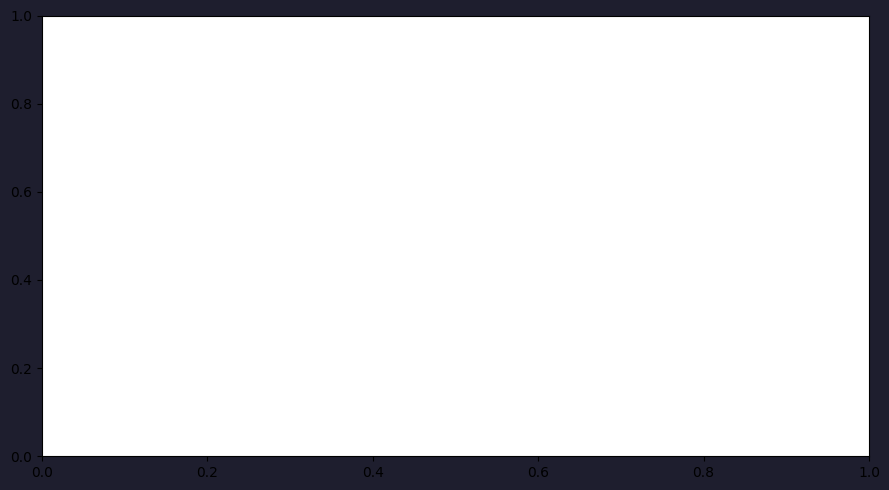

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Definição do Sistema Linear [A|b]
# Matriz 3x3 com vetor coluna b
A_aug = np.array([
    [ 2.0,  1.0, -1.0,   8.0],
    [-3.0, -1.0,  2.0, -11.0],
    [-2.0,  1.0,  2.0,  -3.0]
], dtype=float)


def gerar_passos_gauss(matrix):
    """Executa a eliminação de Gauss e salva o estado da matriz em cada passo."""
    M = matrix.copy()
    n_rows, n_cols = M.shape
    passos = []

    # Estado inicial
    passos.append({
        'matriz': M.copy(),
        'titulo': 'Matriz Aumentada Inicial [A|b]',
        'pivo': None,
        'linha_alvo': None
    })

    # Algoritmo de eliminação
    for k in range(n_rows - 1):
        pivo_val = M[k, k]
        for i in range(k + 1, n_rows):
            fator = M[i, k] / pivo_val
            M[i, :] = M[i, :] - fator * M[k, :]

            # Limpa imprecisões de ponto flutuante proximo de zero
            M[np.abs(M) < 1e-10] = 0.0

            passos.append({
                'matriz': M.copy(),
                'titulo': f'L{i+1} ← L{i+1} - ({fator:.2f}) × L{k+1}',
                'pivo': (k, k),
                'linha_alvo': i
            })

    # Estado final
    passos.append({
        'matriz': M.copy(),
        'titulo': 'Forma Escalonada Concluída (Triangular Superior)',
        'pivo': None,
        'linha_alvo': None
    })

    return passos


# 2. Gerar histórico de passos
passos = gerar_passos_gauss(A_aug)

# 3. Configuração da Animação Visual com Matplotlib
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#1e1e2e')  # Fundo escuro


def atualizar(frame):
    ax.clear()
    ax.set_facecolor('#1e1e2e')
    ax.axis('off')

    dados = passos[frame]
    M = dados['matriz']
    titulo = dados['titulo']
    pivo = dados['pivo']
    linha_alvo = dados['linha_alvo']

    rows, cols = M.shape

    # Título do Passo
    ax.set_title(f"Passo {frame}/{len(passos)-1}: {titulo}",
                 color='#cdd6f4', fontsize=14, fontweight='bold', pad=20)

    # Renderização da grade e dos números
    for r in range(rows):
        for c in range(cols):
            # Cores padrão
            bg_color = '#313244'
            text_color = '#cdd6f4'

            # Destacar Pivô (Verde)
            if pivo and (r, c) == pivo:
                bg_color = '#2e7d32'
            # Destacar Linha Modificada (Vermelho)
            elif linha_alvo is not None and r == linha_alvo:
                bg_color = '#c62828'

            # Desenhar bloco da célula
            rect = plt.Rectangle((c, rows - 1 - r), 0.85, 0.75,
                                 facecolor=bg_color, edgecolor='#45475a', lw=1.5)
            ax.add_patch(rect)

            # Formatação do número
            val = M[r, c]
            val_str = f"{val:.1f}" if val != 0 else "0"

            # Desenhar texto do valor
            ax.text(c + 0.425, rows - 1 - r + 0.375, val_str,
                    color=text_color, fontsize=13, ha='center', va='center', fontweight='bold')

    # Linha divisória vertical para separar a matriz A do vetor b
    ax.plot([cols - 1 - 0.075, cols - 1 - 0.075], [0, rows - 0.25],
            color='#f38ba8', lw=2.5, linestyle='--')

    ax.set_xlim(-0.2, cols + 0.1)
    ax.set_ylim(-0.2, rows + 0.2)


# 4. Iniciar Animação (intervalo de 2.5s por passo)
ani = animation.FuncAnimation(fig, atualizar, frames=len(passos), interval=2500, repeat=True)

plt.tight_layout()
ani.save("gauss.gif", writer="pillow", fps=1) # Guardar o ficheiro primeiro
plt.show() # Mostrar a janela no ecrã depois